# 2D Grid Cells

Aexc = Ainh = 1.0, σexc = 4.8, σinh = 5.0,.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib.animation as animation
from IPython.display import HTML

## Mexican hat

In [12]:
# Global parameters
M = 40
s0 = np.random.uniform(0,0.1, (4, M))
tau = 10e-3
B0 = 1
alpha = 0.1

In [13]:
A_exc = 1
A_inh = 1
sigma_exc = 4.8
sigma_inh = 5

def mexican_hat_2d(xv, yv, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc*np.e**(-(xv**2+yv**2)/sigma_exc**2) - A_inh*np.e**(-(xv**2+yv**2)/sigma_inh**2)

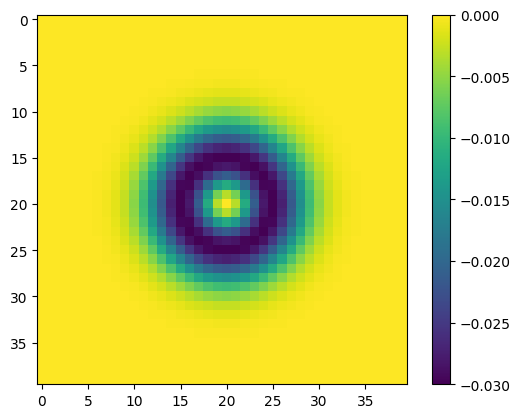

In [14]:
nx, ny = (M, M)
x = np.arange(-M/2, M/2, 1)
y = np.arange(-M/2, M/2, 1)
xv, yv = np.meshgrid(x, y)

w = mexican_hat_2d(xv, yv, A_exc, sigma_exc, A_inh, sigma_inh)
plt.imshow(w)
plt.colorbar()
plt.show()

In [15]:
wE = np.zeros((M, M))
wW = np.zeros((M, M))
wN = np.zeros((M, M))
wS = np.zeros((M, M))
l = 1

wE[:, l:] = w[:, :-l]
wE[:, :l] = w[:, -l:]

wW[:, :-l] = w[:, l:]
wW[:, -l:] = w[:, :l]

wS[l:, :] = w[:-l, :]
wS[:l, :] = w[-l:, :]

wN[:-l, :] = w[l:, :]
wN[-l:, :] = w[:l, :]

wD = np.zeros((4, M, M))
wD[0] = wN
wD[1] = wS
wD[2] = wE
wD[3] = wW

## Initial 2d solver with v = (0,0)

In [23]:
v_y = 0
v_x = 0

def ds_2D_1(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x),
    B0 * (1 - alpha*v_x),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [54]:
def forward_euler(ds, tSpan, dt, s0, rec):

    t = np.arange(tSpan[0], tSpan[1]+dt/100, dt)
    s = np.zeros((4, M, M))
    s = s0
    tstamps = []
    
    for i in range(1, len(t)):

        s = s + dt * ds(s, t[i-1])

        if i % rec == 0:

            tstamps.append(np.sum(np.maximum(0, s), axis=0)) # Saving sums of firing rates at time stamps

    return np.array(tstamps)

In [26]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

history = forward_euler(ds_2D_1, tSpan=[0, 400e-3], dt=1e-3, s0=s0, rec=10)

In [27]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(history)):

    im = ax.imshow(history[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(history[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of grid formation")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

# Testing on different velocities
To test that your grid maps act as a continuous 2D integrator, apply constant velocity vectors in
at least 3 different directions (e.g., purely horizontal, purely vertical, and diagonal). For each velocity
direction, first run your network without any velocity for 300ms, and then apply input velocity for
300ms. Visualize the total 2D firing rate rtotal(x,y) side-by-side at 3 distinct time points (e.g., t=
300, t= 450, t= 600 ms). Describe the integration motion resulting from your velocity input vectors.
Hint: Convolution over the 2D space can be easily implemented using scipy.ndimage.convolve and
setting the boundary conditions accordingly.

### Horizontal

In [28]:
v_y = 0
v_x = [0,1]

def ds_2D_H(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x[int(t//300e-3)]),
    B0 * (1 - alpha*v_x[int(t//300e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [29]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Horizontal = forward_euler(ds_2D_H, [0, 600e-3], 1e-3, s0, 10)

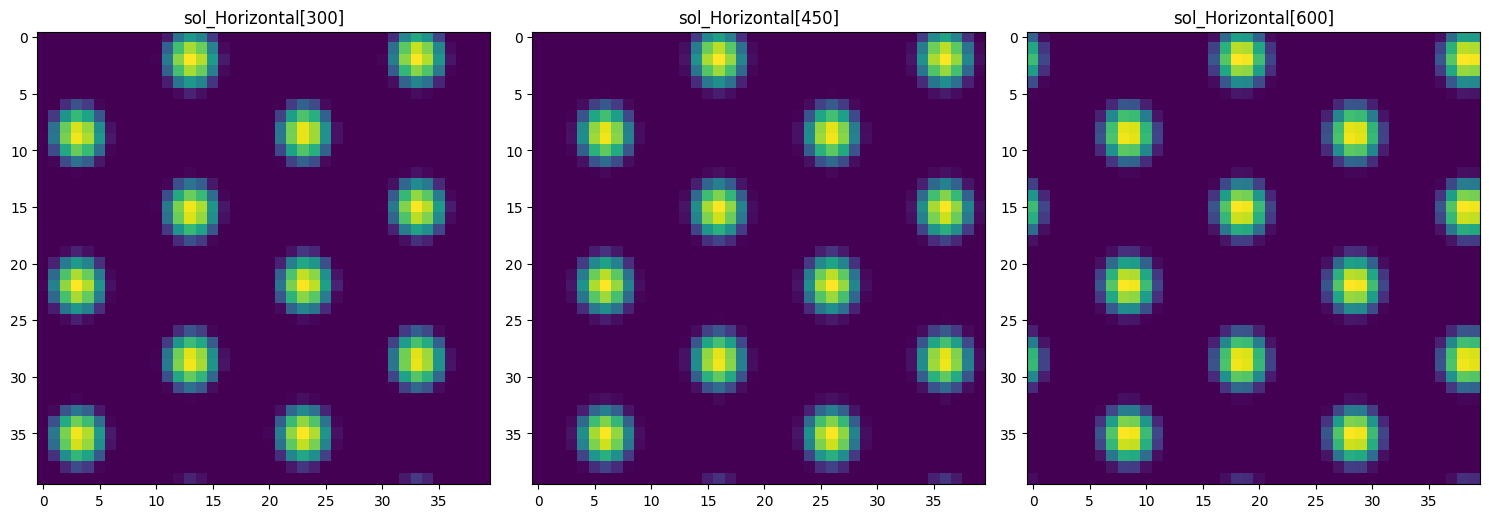

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sol_Horizontal[30])
axes[0].set_title('sol_Horizontal[300]')

axes[1].imshow(sol_Horizontal[45])
axes[1].set_title('sol_Horizontal[450]')

axes[2].imshow(sol_Horizontal[58])
axes[2].set_title('sol_Horizontal[600]')

plt.tight_layout()
plt.show()

In [33]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Horizontal)):

    im = ax.imshow(sol_Horizontal[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Horizontal[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of horizontal velocity v = [1, 0]")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

### Vertical

In [34]:
v_y = [0,1]
v_x = [0,0]

def ds_2D_V(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//300e-3)]),
    B0 * (1 - alpha*v_y[int(t//300e-3)]),
    B0 * (1 + alpha*v_x[int(t//300e-3)]),
    B0 * (1 - alpha*v_x[int(t//300e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [35]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Vertical = forward_euler(ds_2D_V, [0, 600e-3], 1e-3, s0, 10)

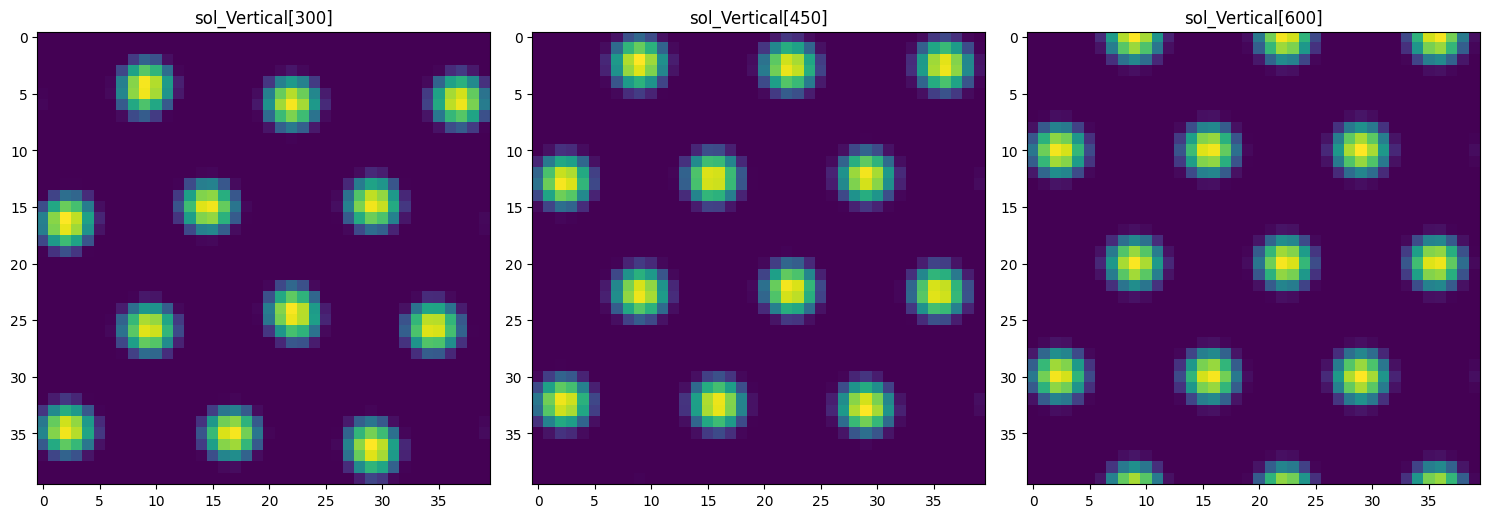

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sol_Vertical[30])
axes[0].set_title('sol_Vertical[300]')

axes[1].imshow(sol_Vertical[45])
axes[1].set_title('sol_Vertical[450]')

axes[2].imshow(sol_Vertical[58])
axes[2].set_title('sol_Vertical[600]')

plt.tight_layout()
plt.show()

In [37]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Vertical)):

    im = ax.imshow(sol_Vertical[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Vertical[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of vertical velocity v = [0, 1]")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

### Diagonal

In [38]:
v_y = [0,0.7]
v_x = [0,0.7]

def ds_2D_D(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//300e-3)]),
    B0 * (1 - alpha*v_y[int(t//300e-3)]),
    B0 * (1 + alpha*v_x[int(t//300e-3)]),
    B0 * (1 - alpha*v_x[int(t//300e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [39]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Diagonal = forward_euler(ds_2D_D, [0, 600e-3], 1e-3, s0, 10)

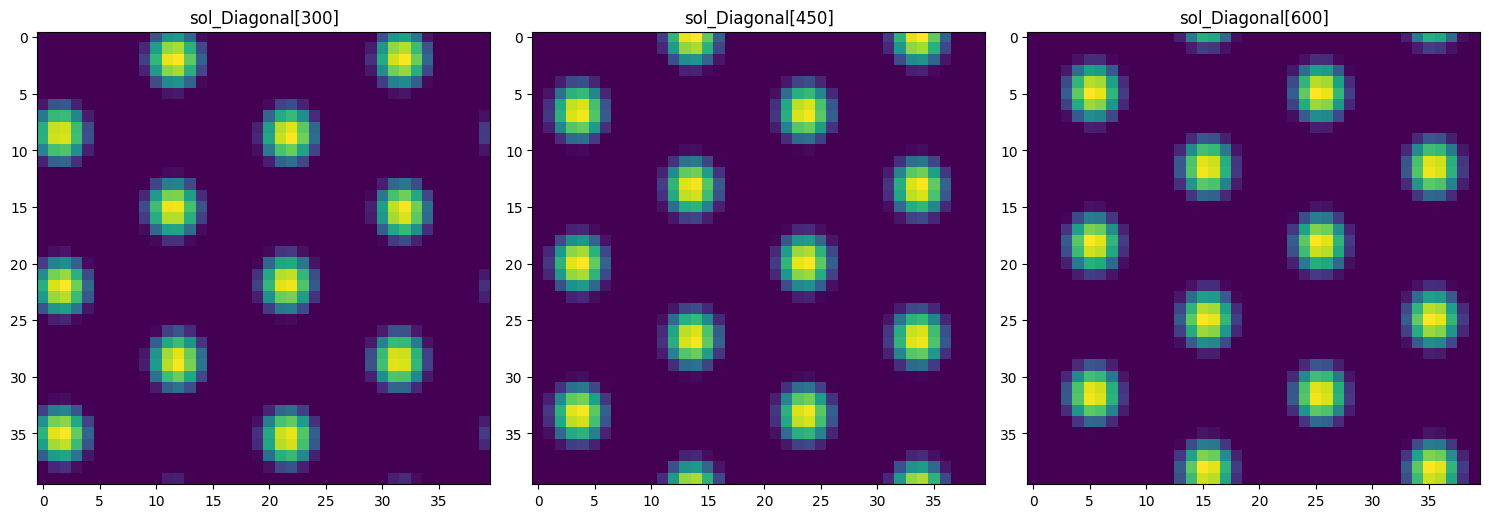

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sol_Diagonal[30])
axes[0].set_title('sol_Diagonal[300]')

axes[1].imshow(sol_Diagonal[45])
axes[1].set_title('sol_Diagonal[450]')

axes[2].imshow(sol_Diagonal[58])
axes[2].set_title('sol_Diagonal[600]')

plt.tight_layout()
plt.show()

In [41]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Diagonal)):

    im = ax.imshow(sol_Diagonal[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Diagonal[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of diagonal velocity v = [0.7, 0.7]")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

# Testing on random velocities (Bonus)

In [45]:
speeds = np.random.uniform(1,2, size=11)
speeds[0] = 0
thetas = np.random.uniform(0, 2*np.pi, size=11)
vs = np.zeros((11, 2))
for i in range(11):
    vs[i,0] = speeds[i]*np.cos(thetas[i])
    vs[i,1] = speeds[i]*np.sin(thetas[i])

In [46]:
v_y = vs[:,1]
v_x = vs[:,0]

def ds_2D_Rand(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//100e-3)]),
    B0 * (1 - alpha*v_y[int(t//100e-3)]),
    B0 * (1 + alpha*v_x[int(t//100e-3)]),
    B0 * (1 - alpha*v_x[int(t//100e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [55]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_RandV = forward_euler(ds_2D_Rand, [0, 1100e-3], 1e-3, s0, 10)

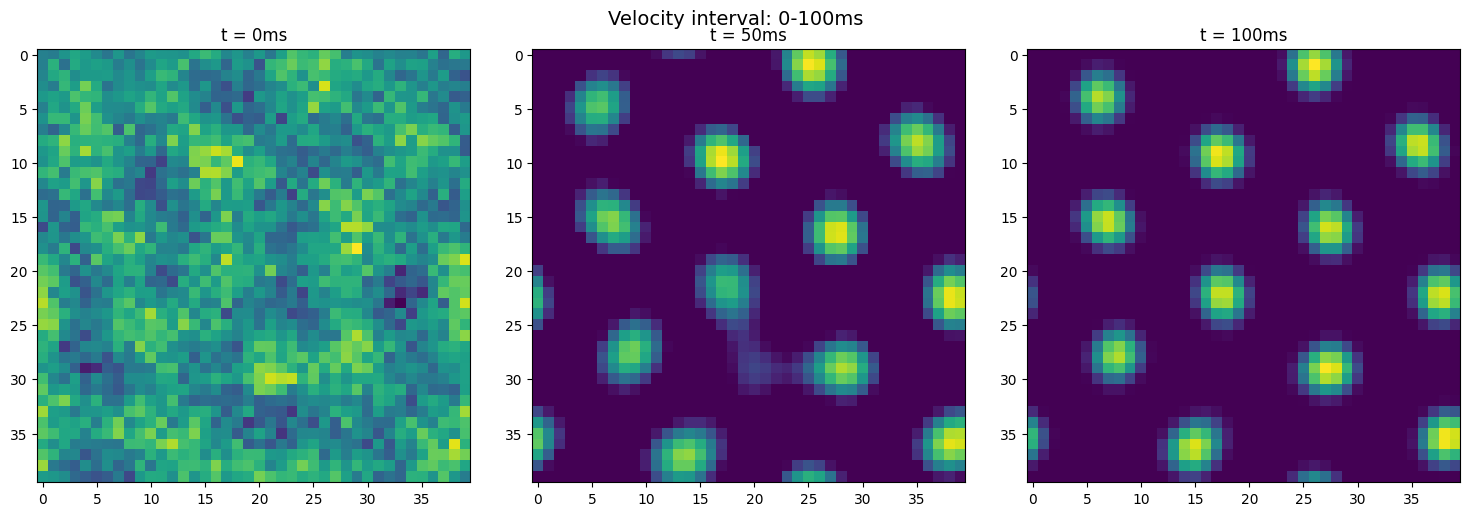

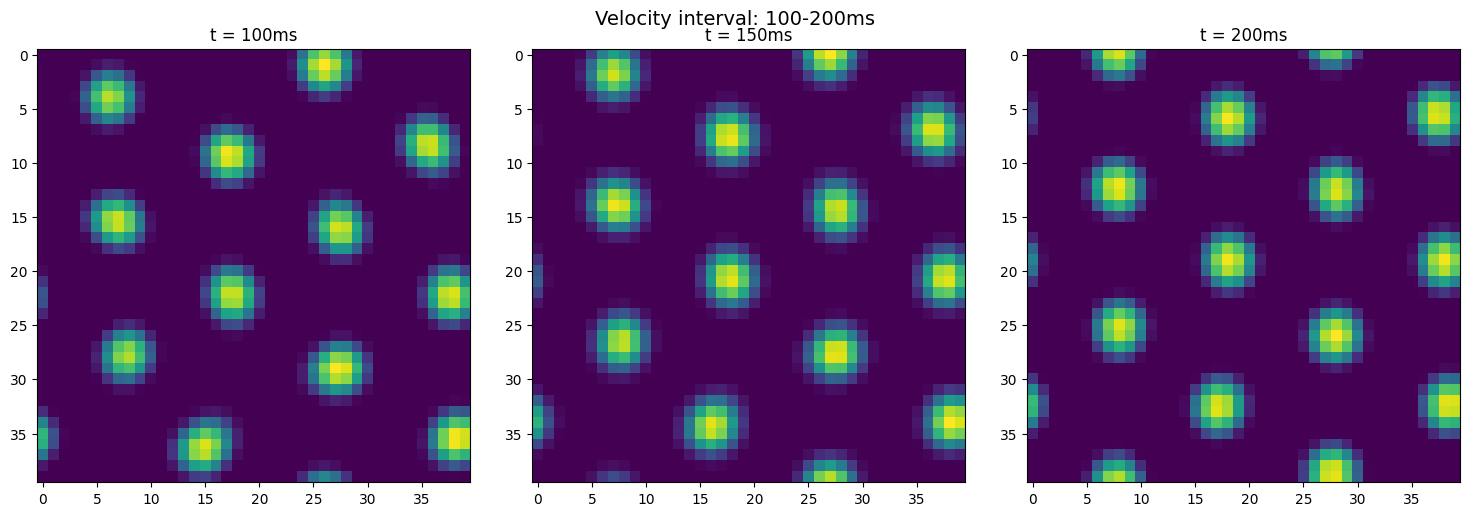

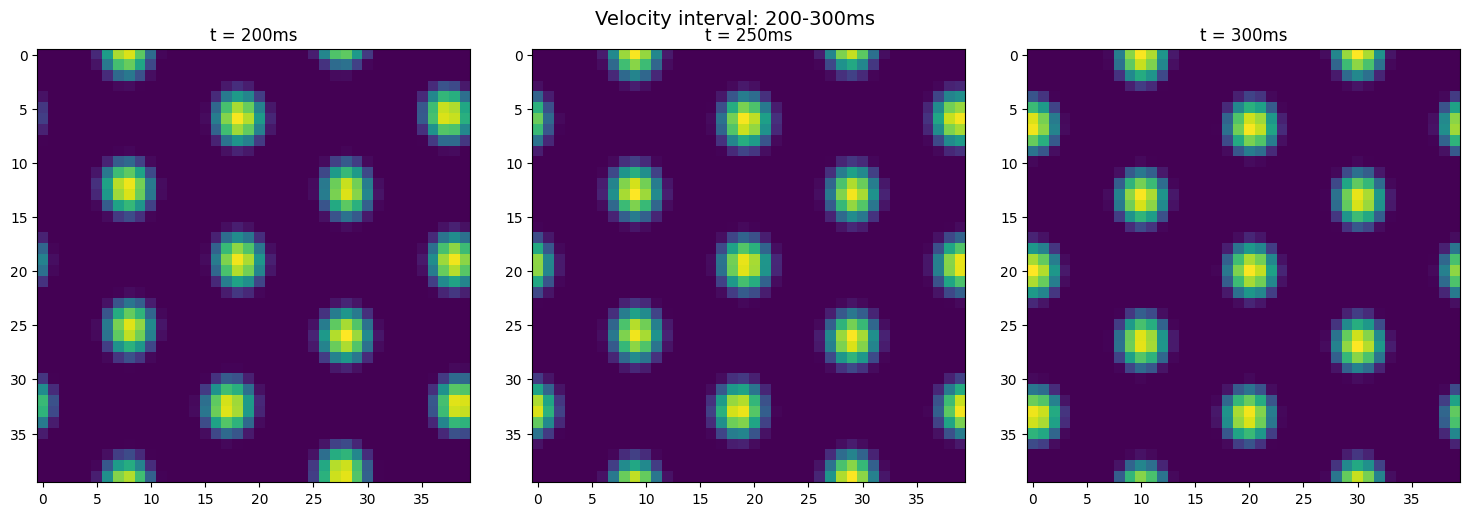

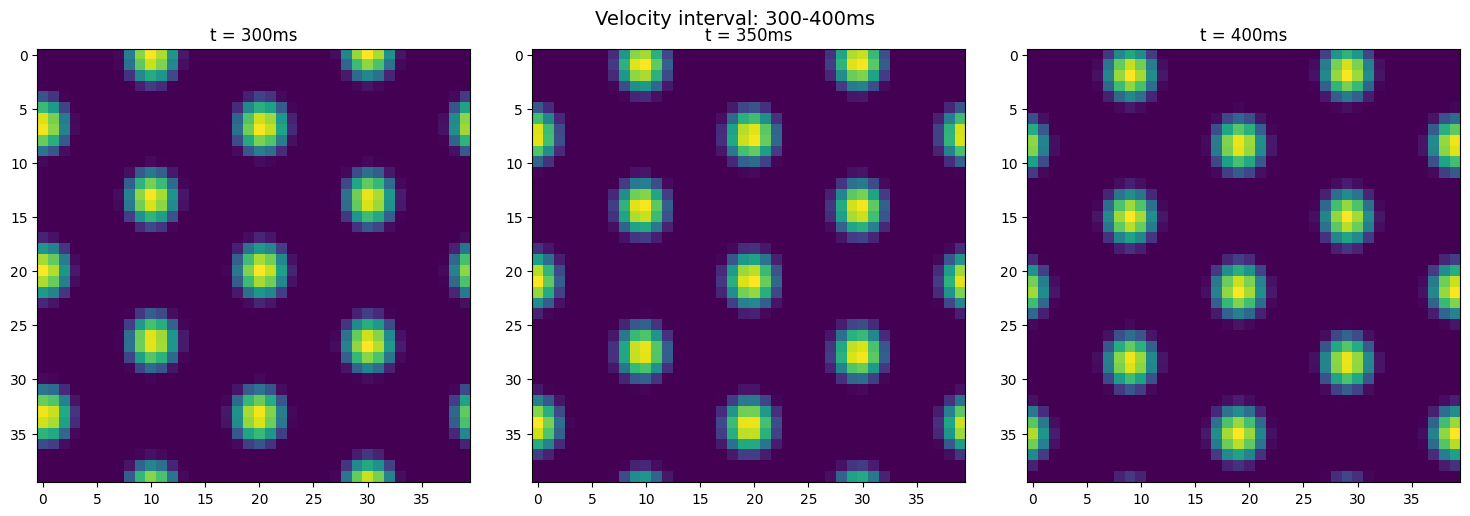

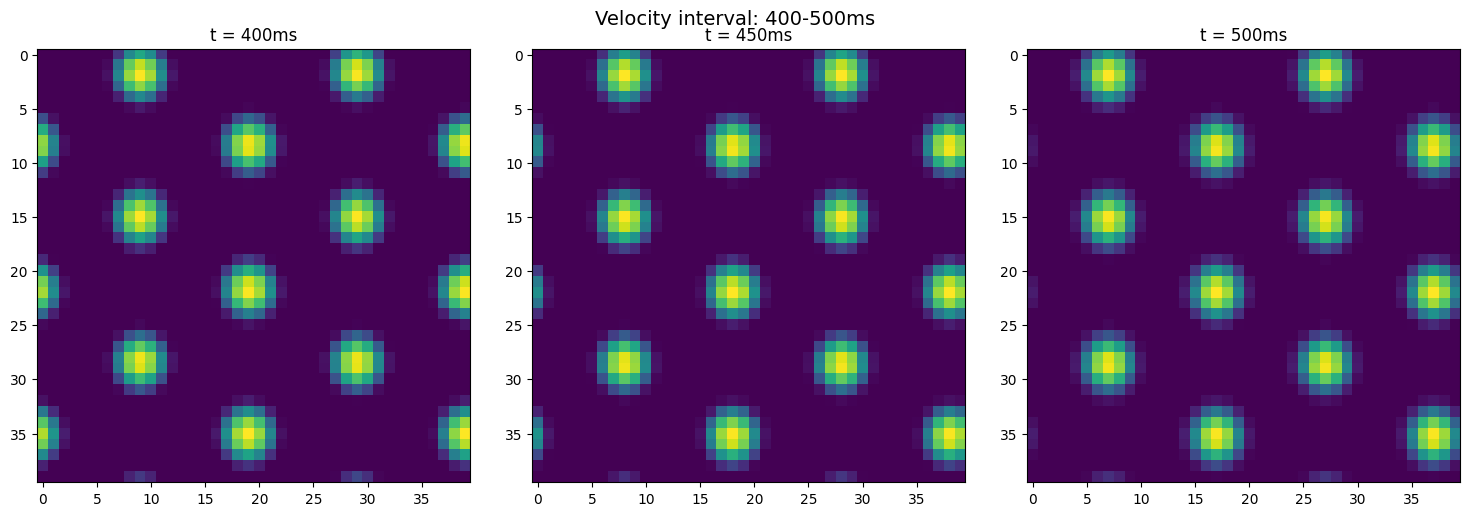

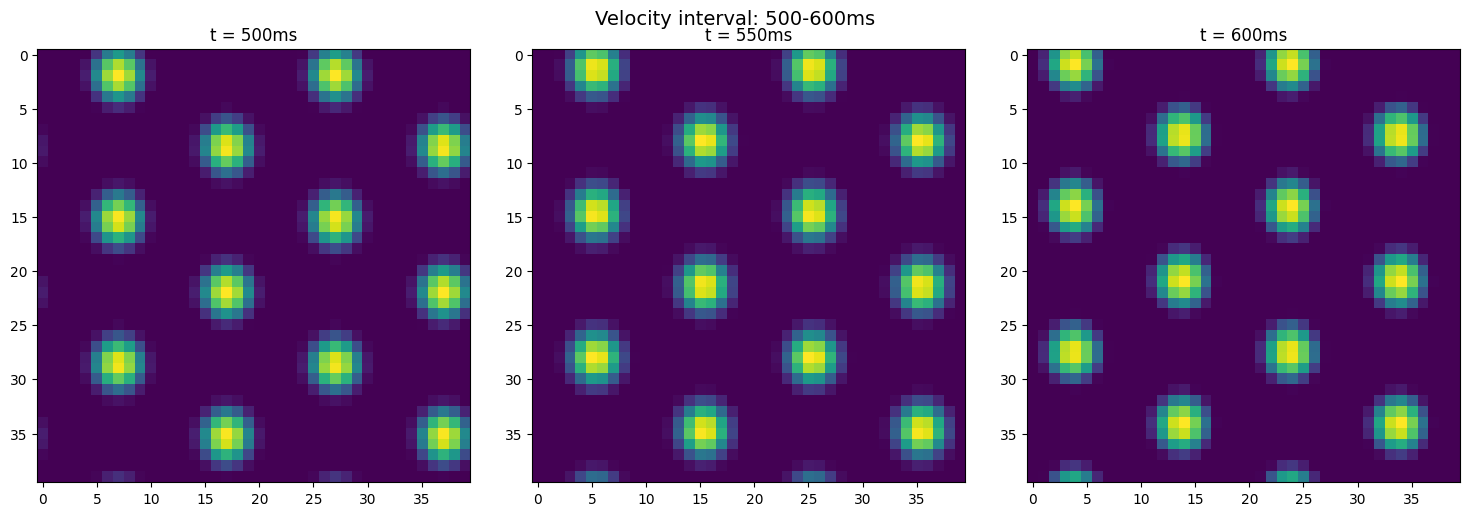

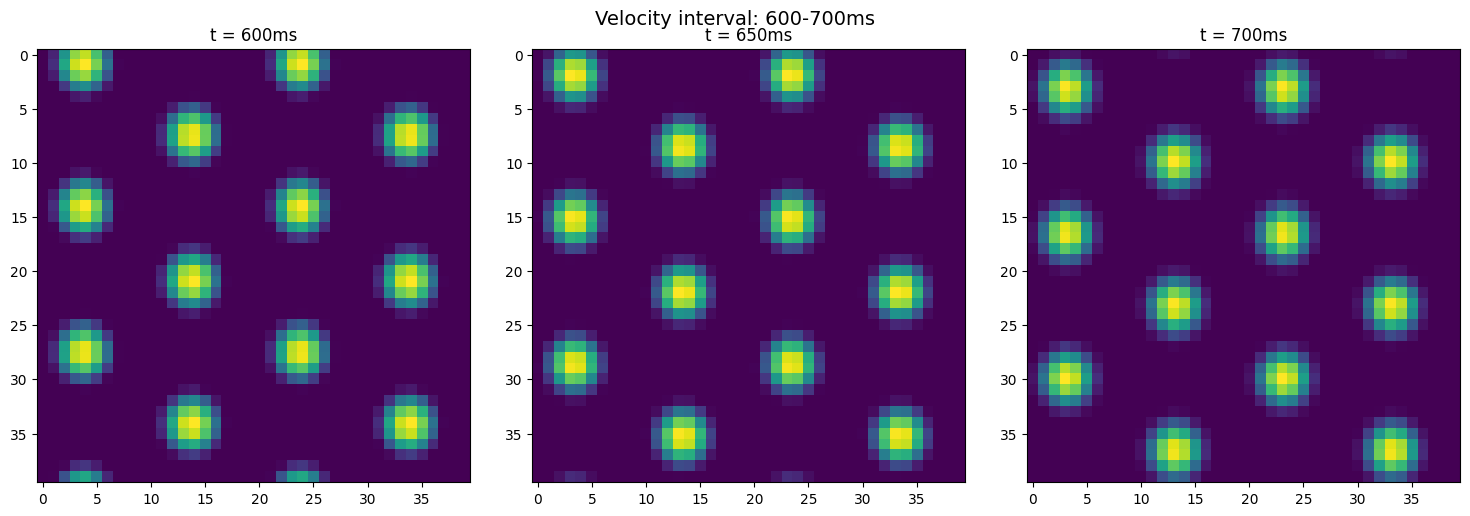

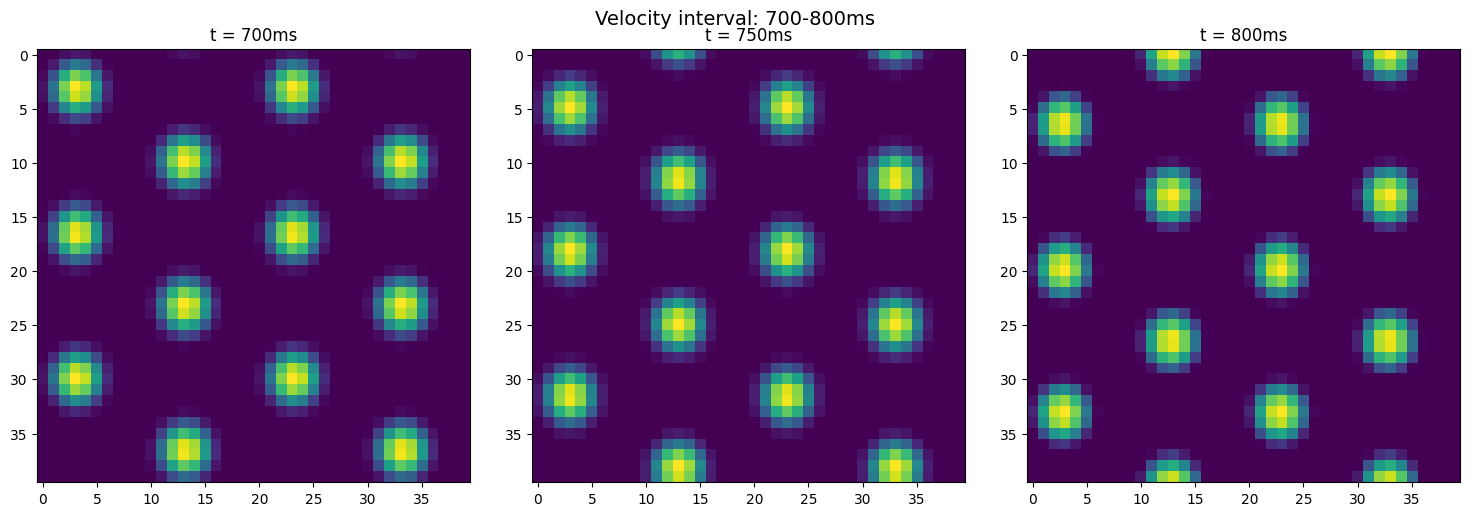

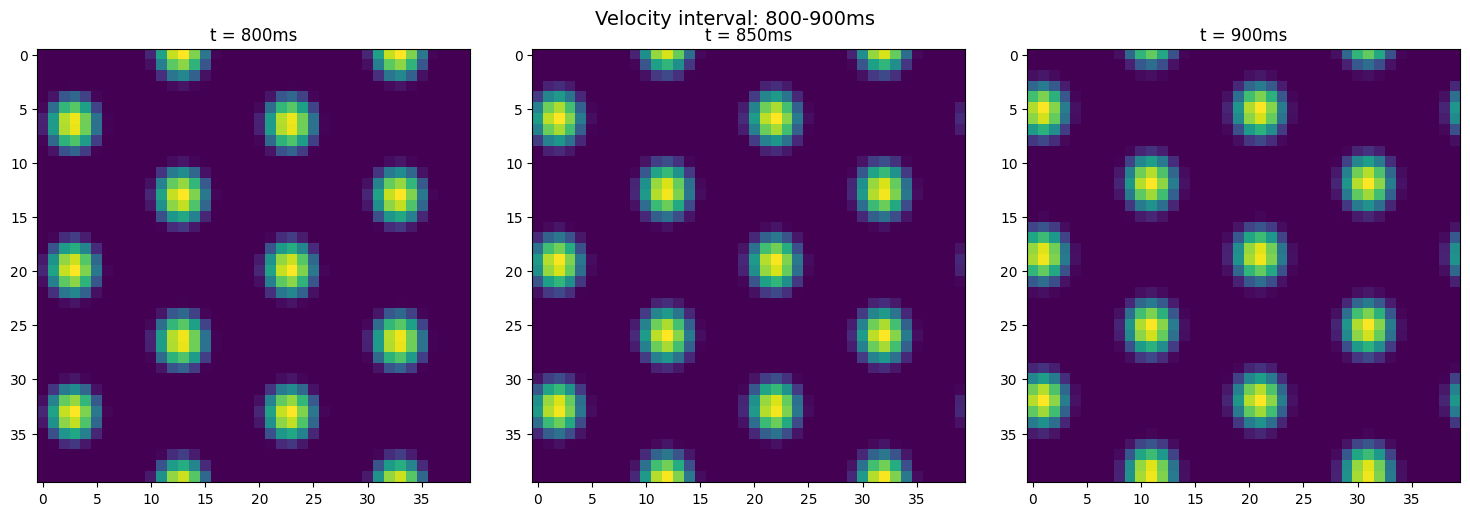

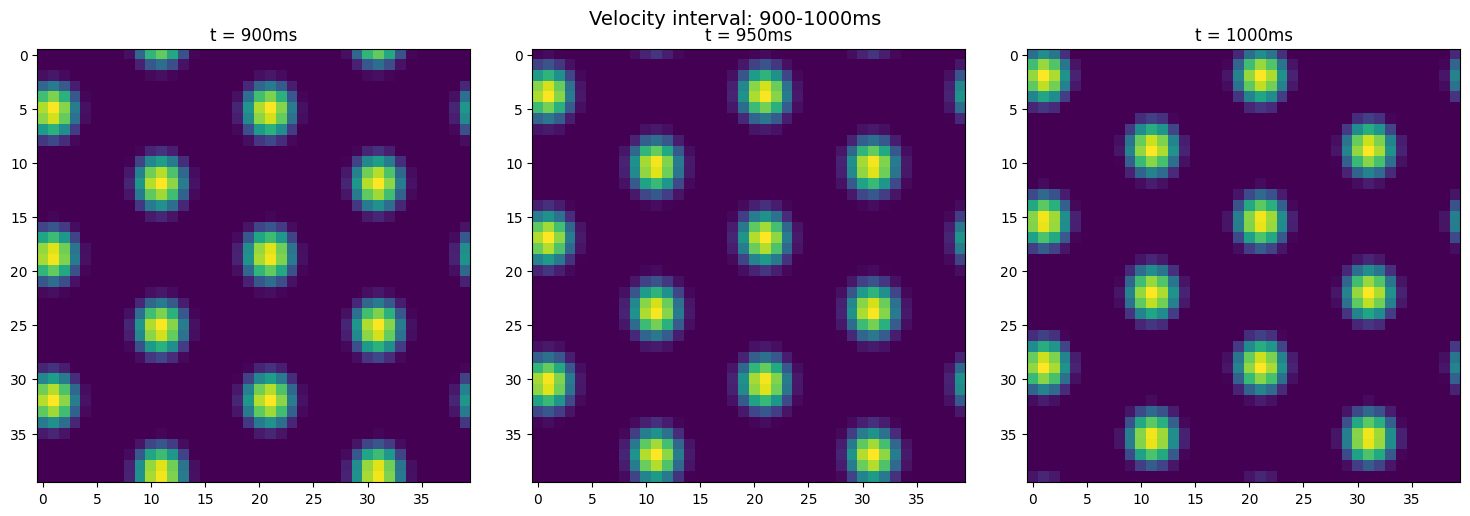

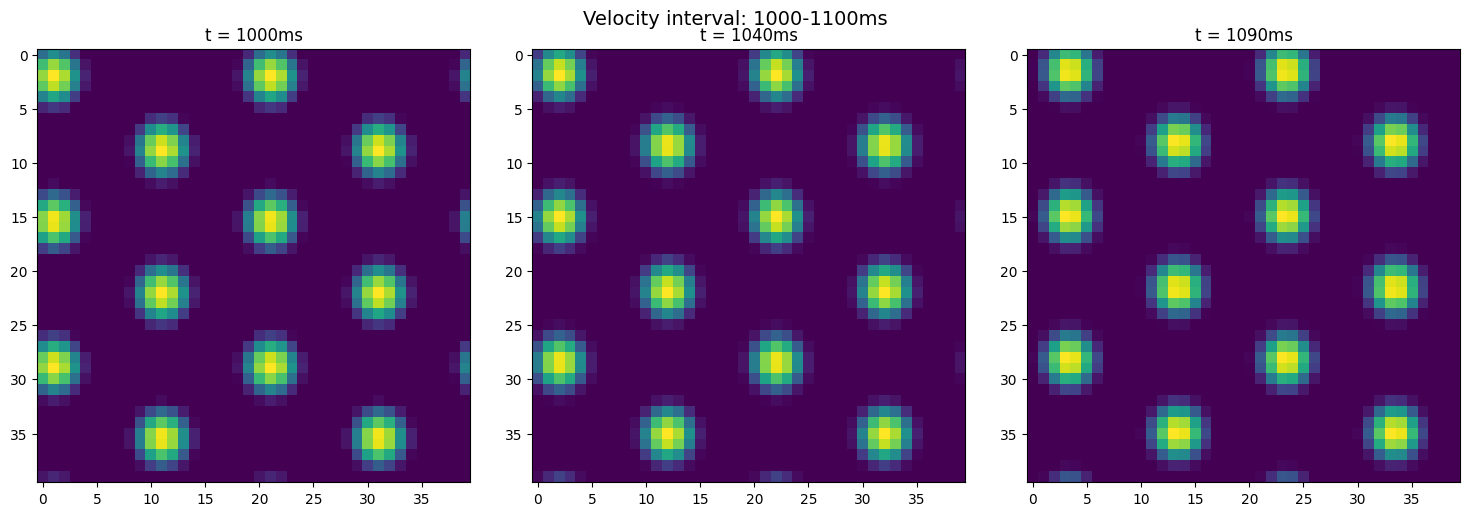

In [56]:
# Velocity intervals: 0-100ms, 100-200ms, ..., 1000-1100ms
# sol_RandV[i] is solution at t = i*10ms
# Each 100ms interval = indices 0-10, 10-20, 20-30, ...

intervals = [
    (0, 10, "0-100ms"),
    (10, 20, "100-200ms"),
    (20, 30, "200-300ms"),
    (30, 40, "300-400ms"),
    (40, 50, "400-500ms"),
    (50, 60, "500-600ms"),
    (60, 70, "600-700ms"),
    (70, 80, "700-800ms"),
    (80, 90, "800-900ms"),
    (90, 100, "900-1000ms"),
    (100, 109, "1000-1100ms"),
]

for start, end, label in intervals:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Velocity interval: {label}', fontsize=14)

    mid = (start + end) // 2

    axes[0].imshow(sol_RandV[start])
    axes[0].set_title(f't = {start * 10}ms')

    axes[1].imshow(sol_RandV[mid])
    axes[1].set_title(f't = {mid * 10}ms')

    axes[2].imshow(sol_RandV[end])
    axes[2].set_title(f't = {end * 10}ms')

    plt.tight_layout()
    plt.show()

In [57]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_RandV)):

    im = ax.imshow(sol_RandV[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_RandV[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of random velocities")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

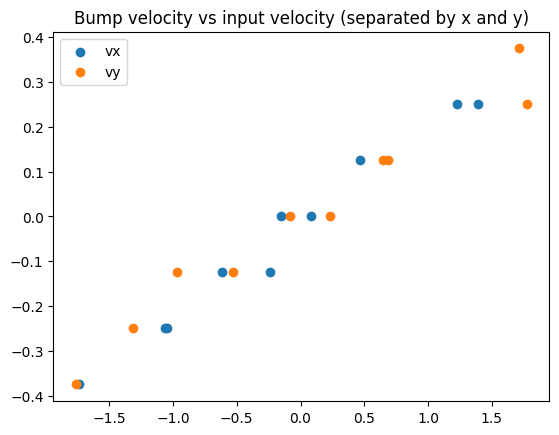

In [61]:

bVel_x = np.zeros(11)
bVel_y = np.zeros(11)


for i in range(0, 109, 10):

    k0 = np.array(np.unravel_index(np.argmax(sol_RandV[i, 10:30, 10:30], axis=None), sol_RandV[i, 10:30, 10:30].shape)) + [10, 10]
    ks = [k0]
    for j in range(1, 9):
        k0 = np.array(np.unravel_index(np.argmax(sol_RandV[i+j, k0[0]-5 : k0[0]+5, k0[1]-5 : k0[1]+5], axis=None), sol_RandV[i+j, k0[0]-5 : k0[0]+5, k0[1]-5 : k0[1]+5].shape))+ np.array([k0[0]-5, k0[1]-5])
        ks.append(k0) 
    
    
    ks = np.array(ks)

    bVel_x[i//10] = np.mean(ks[1:, 1]-ks[:-1, 1])
    bVel_y[i//10] = -np.mean(ks[1:, 0]-ks[:-1, 0])


# What should the units be here? Do we divide by 300e-3? or by 300?
plt.title('Bump velocity vs input velocity (separated by x and y)')
plt.scatter(vs[1:, 0], bVel_x[1:], label='vx')
plt.scatter(vs[1:, 1], bVel_y[1:], label = 'vy')
plt.legend()
plt.show()
